In [1]:
from pathlib import Path
from google.colab import drive
from pathlib import Path
from google.colab import files

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:

# Carpeta donde esta guardada la imagen en Drive
ruta_carpeta = Path(
    "/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/TP_006/TP 006/IMAGENES/ORIGINALES"
)


nombre_imagen_luz = "punto07.jpeg"

# Ruta completa
ruta_imagen_luz = ruta_carpeta / nombre_imagen_luz


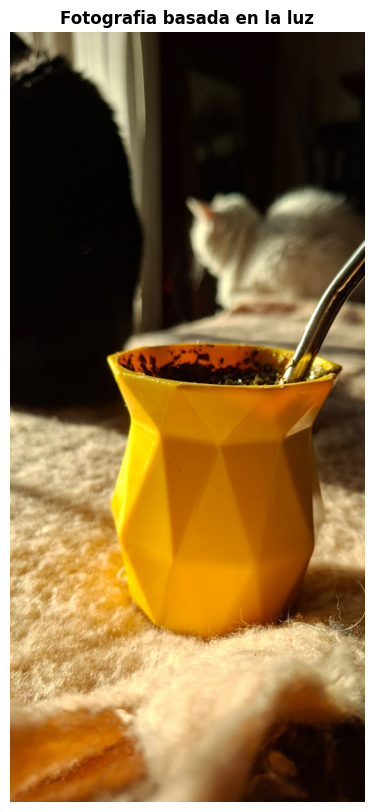

In [4]:
def cargar_rgb(ruta):
    """
    Carga una imagen y la convierte de BGR a RGB
    para visualizarla correctamente con Matplotlib.
    """

    imagen_bgr = cv2.imread(
        str(ruta),
        cv2.IMREAD_COLOR
    )

    if imagen_bgr is None:
        raise FileNotFoundError(
            f"No se pudo leer la imagen: {ruta}"
        )

    imagen_rgb = cv2.cvtColor(
        imagen_bgr,
        cv2.COLOR_BGR2RGB
    )

    return imagen_rgb


# Cargamos la imagen
imagen_luz_rgb = cargar_rgb(ruta_imagen_luz)

plt.figure(figsize=(7, 10))

plt.imshow(imagen_luz_rgb)

plt.title(
    "Fotografia basada en la luz",
    fontweight="bold"
)

plt.axis("off")

plt.show()


La escena fue capturada utilizando luz lateral dura proveniente de la ventana. La iluminación ingresa desde la izquierda de la imagen y atraviesa la mesa generando sombras definidas y alto contraste.
La fotografía fue tomada durante la mañana, utilizando luz natural cálida cercana a la hora dorada. Esto aporta tonos amarillos y una atmósfera más íntima.

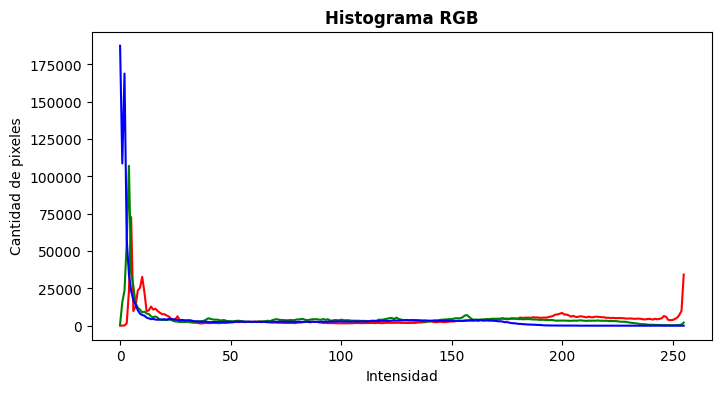

In [5]:

# =========================
# 3. HISTOGRAMA RGB
# =========================

plt.figure(figsize=(8, 4))

colores = ("red", "green", "blue")

for i, color in enumerate(colores):

    histograma = cv2.calcHist(
        [imagen_luz_rgb],
        [i],
        None,
        [256],
        [0, 256]
    )

    plt.plot(
        histograma,
        color=color
    )

plt.title(
    "Histograma RGB",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de pixeles")

plt.show()


In [6]:

# =========================
# 4. ESCALA DE GRISES
# =========================

# Convertimos la imagen a escala de grises
# para enfatizar contraste, volumen y sombras.

imagen_luz_gris = cv2.cvtColor(
    imagen_luz_rgb,
    cv2.COLOR_RGB2GRAY
)



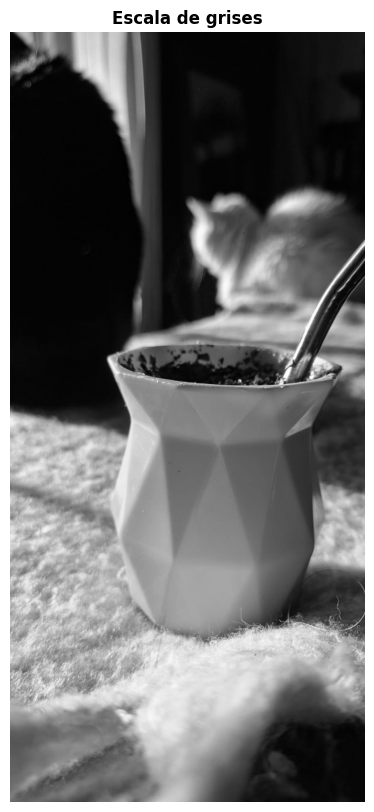

In [7]:

# =========================
# 5. VISUALIZACION EN GRISES
# =========================

plt.figure(figsize=(7, 10))

plt.imshow(
    imagen_luz_gris,
    cmap="gray"
)

plt.title(
    "Escala de grises",
    fontweight="bold"
)

plt.axis("off")

plt.show()


El contraste entre las zonas iluminadas y las sombras profundas genera profundidad visual y separa los distintos planos de la escena.

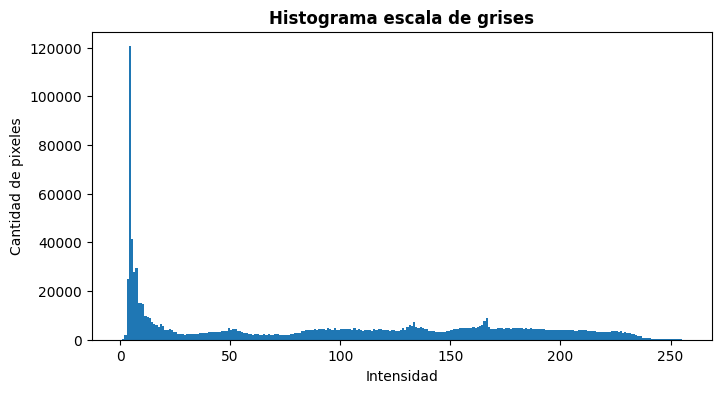

In [8]:

# =========================
# 6. HISTOGRAMA ESCALA DE GRISES
# =========================

plt.figure(figsize=(8, 4))

plt.hist(
    imagen_luz_gris.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title(
    "Histograma escala de grises",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de pixeles")

plt.show()


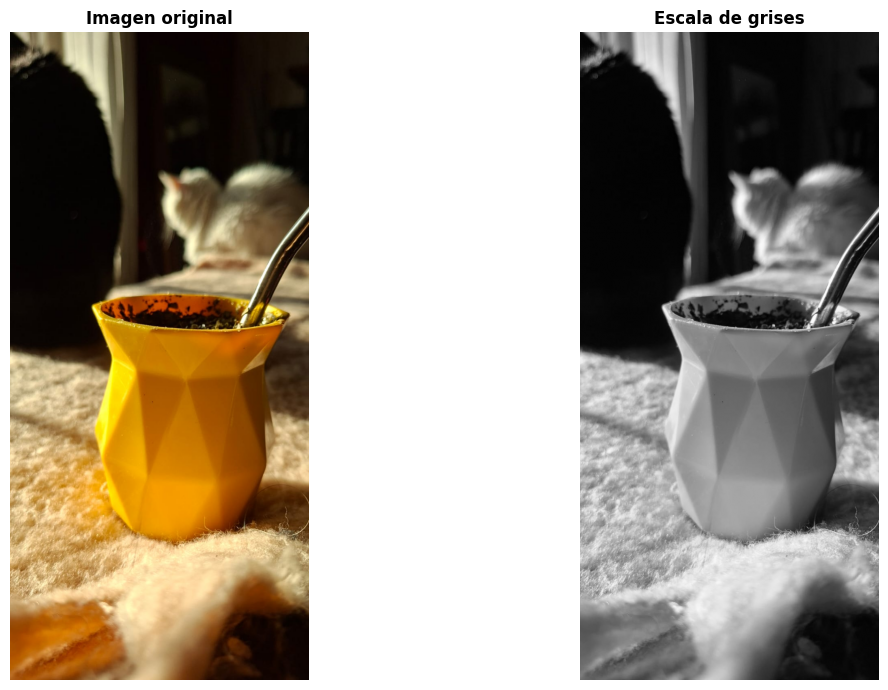

In [9]:


# =========================
# 7. COMPARACION ENTRE IMAGENES
# =========================

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)

plt.imshow(imagen_luz_rgb)

plt.title(
    "Imagen original",
    fontweight="bold"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    imagen_luz_gris,
    cmap="gray"
)

plt.title(
    "Escala de grises",
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.show()


La dirección lateral de la luz permite observar claramente cómo las zonas iluminadas y las zonas en sombra modelan el volumen de los objetos.

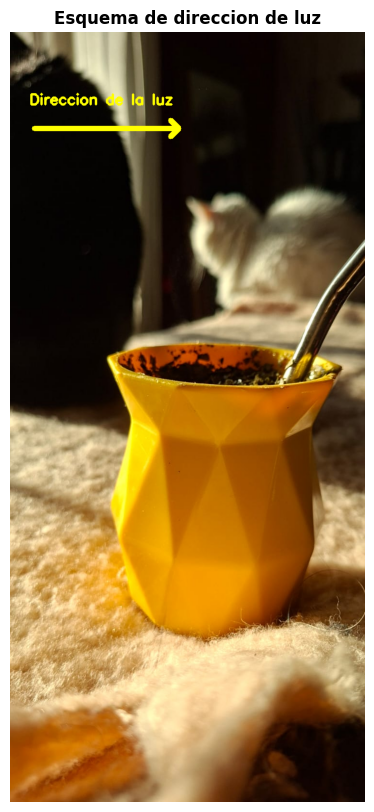

In [10]:

# =========================
# 8. DIRECCION DE LA LUZ
# =========================

# Creamos una copia para dibujar el esquema.

imagen_luz_esquema = imagen_luz_rgb.copy()

# Dibujamos una flecha indicando
# la direccion aproximada de la luz.

cv2.arrowedLine(
    imagen_luz_esquema,
    (50, 200),
    (350, 200),
    (255, 255, 0),
    10,
    tipLength=0.08
)

cv2.putText(
    imagen_luz_esquema,
    "Direccion de la luz",
    (40, 150),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 255, 0),
    3
)

plt.figure(figsize=(7, 10))

plt.imshow(imagen_luz_esquema)

plt.title(
    "Esquema de direccion de luz",
    fontweight="bold"
)

plt.axis("off")

plt.show()


Las sombras largas proyectadas sobre la mesa ayudan a dirigir la mirada hacia el centro de la imagen y refuerzan la sensación de profundidad.
La luz lateral resalta las texturas de la manta, la yerba y la superficie del mate, haciendo visibles detalles que con una luz frontal quedarían más planos.
La iluminación lateral produce volumen al generar diferencias de luminosidad entre las caras iluminadas y las zonas oscuras del objeto.
La combinación entre luz cálida, sombras suaves en el fondo y desenfoque genera una atmósfera tranquila y contemplativa.

¿La luz revela o esconde?

La luz revela las texturas y el volumen del mate, pero al mismo tiempo esconde parte del fondo mediante sombras y desenfoque.

¿Genera textura?

Sí. La iluminación lateral enfatiza las irregularidades y relieves de los materiales presentes en la escena.

¿Construye atmósfera?

Sí. La luz cálida de la mañana construye una atmósfera íntima y serena.

¿Cómo cambia el volumen?

El volumen aumenta visualmente porque la luz lateral genera zonas iluminadas y zonas oscuras que modelan tridimensionalmente los objetos.


In [11]:

# =========================
# 9. EXPORTACION DIRECTA
# =========================

# Imagen original
cv2.imwrite(
    "punto07_fotografia_luz_original.jpg",
    cv2.cvtColor(
        imagen_luz_rgb,
        cv2.COLOR_RGB2BGR
    )
)

# Escala de grises
cv2.imwrite(
    "punto07_fotografia_luz_grises.jpg",
    imagen_luz_gris
)

# Esquema de luz
cv2.imwrite(
    "punto07_esquema_luz.jpg",
    cv2.cvtColor(
        imagen_luz_esquema,
        cv2.COLOR_RGB2BGR
    )
)

# Comparacion final
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)

plt.imshow(imagen_luz_rgb)

plt.title(
    "Imagen original",
    fontweight="bold"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    imagen_luz_gris,
    cmap="gray"
)

plt.title(
    "Escala de grises",
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "punto07_comparacion.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()


# Descargas
files.download(
    "punto07_fotografia_luz_original.jpg"
)

files.download(
    "punto07_fotografia_luz_grises.jpg"
)

files.download(
    "punto07_esquema_luz.jpg"
)

files.download(
    "punto07_comparacion.png"
)

print("Exportacion completada.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exportacion completada.
